In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, ConfusionMatrixDisplay
from tabulate import tabulate

import load.load_dataset as ds
import load.load_net as nt

import joblib

In [2]:
def plot_roc(y_val, result1, result2, result3, result4, result5, result6, dataset_name, class_idx = None):
    y_val_labels = y_val.detach().numpy().argmax(axis=1)

    roc1 = roc_auc_score(y_val_labels, result1['pred_proba'][0][:,1])
    fpr1, tpr1, _ = roc_curve(y_val_labels, result1['pred_proba'][0][:,1])

    roc2 = roc_auc_score(y_val_labels, result2['pred_proba'][0][:,1])
    fpr2, tpr2, _ = roc_curve(y_val_labels, result2['pred_proba'][0][:,1])

    roc3 = roc_auc_score(y_val_labels, result3['pred_proba'][0][:,1])
    fpr3, tpr3, _ = roc_curve(y_val_labels, result3['pred_proba'][0][:,1])

    roc4 = roc_auc_score(y_val_labels, result4['pred_proba'][0][:,1])
    fpr4, tpr4, _ = roc_curve(y_val_labels, result4['pred_proba'][0][:,1])

    roc5 = roc_auc_score(y_val_labels, result5['pred_proba'][0][:,1])
    fpr5, tpr5, _ = roc_curve(y_val_labels, result5['pred_proba'][0][:,1])

    roc6 = roc_auc_score(y_val_labels, result6['pred_proba'][0][:,1])
    fpr6, tpr6, _ = roc_curve(y_val_labels, result6['pred_proba'][0][:,1])

    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    plt.figure(figsize=(6,6))
    ax[0].set_title('SmallNN')
    ax[0].plot(fpr1, tpr1, color='black', label=f'Small - {roc1:.4f}')
    ax[0].plot(fpr4, tpr4, color='red', label=f'Reg 0.1 dropout - {roc4:.4f}')
    ax[0].plot([0,1],[0,1], color='grey', linestyle='--', label='Random')
    ax[0].set_xlabel('False Positive Rate')
    ax[0].set_ylabel('True Positive Rate')
    ax[0].legend()

    ax[1].set_title('DeeperNN')
    ax[1].plot(fpr2, tpr2, color='black', label=f'Deeper - {roc2:.4f}')
    ax[1].plot(fpr5, tpr5, color='red', label=f'Reg 0.1 dropout - {roc5:.4f}')
    ax[1].plot([0,1],[0,1], color='grey', linestyle='--', label='Random')
    ax[1].set_xlabel('False Positive Rate')
    ax[1].set_ylabel('True Positive Rate')
    ax[1].legend()

    ax[2].set_title('ShallowNN')
    ax[2].plot(fpr3, tpr3, color='black', label=f'Shallow - {roc3:.4f}')
    ax[2].plot(fpr6, tpr6, color='red', label=f'Reg 0.1 dropout - {roc6:.4f}')
    ax[2].plot([0,1],[0,1], color='grey', linestyle='--', label='Random')
    ax[2].set_xlabel('False Positive Rate')
    ax[2].set_ylabel('True Positive Rate')
    ax[2].legend()

    plt.tight_layout()
    plt.show()


In [3]:
def plot_conf_matrix(y_val, result1, result2, result3, title = ['', '', '']):
    cm1 = result1['confusion_matrix'][0]
    cm2 = result2['confusion_matrix'][0]
    cm3 = result3['confusion_matrix'][0]
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1)
    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2)
    disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3)
    ax[0].set_title(title[0])
    ax[1].set_title(title[1])
    ax[2].set_title(title[2])
    disp1.plot(cmap=plt.cm.Blues, ax=ax[0])
    disp2.plot(cmap=plt.cm.Blues, ax=ax[1])
    disp3.plot(cmap=plt.cm.Blues, ax=ax[2])
    ax[0].grid(False)
    ax[1].grid(False)
    ax[2].grid(False)
    plt.show()

In [4]:
def eval_net(dataset_name, model_name, verbose = False, print_report = False):

    history = joblib.load(f'./models/histories/{dataset_name}_{model_name}_history.joblib')
    results = joblib.load(f'./models/results/{dataset_name}_{model_name}_results.joblib')
    acc_train = history['train_acc'][-1]
    acc_val = history['val_acc'][-1]

    if verbose:
        axis = np.linspace(0, len(history['train_loss']), len(history['train_loss']))
        fig, ax = plt.subplots(1, 2, figsize = [12,5])
        ax[0].plot(axis, history['train_loss'], label='Train Loss')
        ax[0].plot(axis, history['val_loss'], label='Val Loss')
        ax[0].set_title('Loss')
        ax[0].legend()

        ax[1].plot(axis, history['train_acc'], label='Train Accuracy')
        ax[1].plot(axis, history['val_acc'], label='Val Accuracy')
        ax[1].set_title('Accuracy')
        ax[1].legend()
        plt.tight_layout()
        plt.show()
    if print_report:
        print(f"\n{model_name}")
        print(results['classification_report'][0])
    return results, acc_train, acc_val


# ADULT

structure of the nets for dataset adult:

In [5]:
read = joblib.load('./load/nets/model_adult_dict.joblib')
read

{'model1': smallNN(
   (linear1): Linear(in_features=97, out_features=256, bias=True)
   (sigmoid1): ReLU()
   (linear2): Linear(in_features=256, out_features=128, bias=True)
   (sigmoid2): ReLU()
   (linear3): Linear(in_features=128, out_features=64, bias=True)
   (sigmoid3): ReLU()
   (linear4): Linear(in_features=64, out_features=32, bias=True)
   (sigmoid4): ReLU()
   (linear5): Linear(in_features=32, out_features=2, bias=True)
   (softmax): Softmax(dim=None)
 ),
 'model2': deeperNN(
   (linear1): Linear(in_features=97, out_features=1024, bias=True)
   (relu1): ReLU()
   (linear2): Linear(in_features=1024, out_features=512, bias=True)
   (relu2): ReLU()
   (linear3): Linear(in_features=512, out_features=128, bias=True)
   (relu3): ReLU()
   (linear4): Linear(in_features=128, out_features=64, bias=True)
   (relu4): ReLU()
   (linear5): Linear(in_features=64, out_features=32, bias=True)
   (relu5): ReLU()
   (linear6): Linear(in_features=32, out_features=2, bias=True)
   (softmax): S

In [6]:
dataset_name = "adult"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

adult_smallNN, adult_acc_train_model1, adult_acc_val_model1 = eval_net(dataset_name, 'model1', print_report = True)
adult_deeperNN, adult_acc_train_model2, adult_acc_val_model2 = eval_net(dataset_name, 'model2', print_report = True)
adult_shallowNN, adult_acc_train_model3, adult_acc_val_model3 = eval_net(dataset_name, 'model3', print_report = True)

adult_regSmallNN, adult_acc_train_model1r, adult_acc_val_model1r = eval_net(dataset_name, 'model1r', print_report = True)
adult_regDeeperNN, adult_acc_train_model2r, adult_acc_val_model2r = eval_net(dataset_name, 'model2r', print_report = True)
adult_regShallowNN, adult_acc_train_model3r, adult_acc_val_model3r = eval_net(dataset_name, 'model3r', print_report = True)

(36177, 12) (8045, 12) (1000, 12)

model1
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      6033
           1       0.69      0.60      0.65      2012

    accuracy                           0.83      8045
   macro avg       0.78      0.76      0.77      8045
weighted avg       0.83      0.83      0.83      8045


model2
              precision    recall  f1-score   support

           0       0.87      0.92      0.90      6033
           1       0.71      0.61      0.65      2012

    accuracy                           0.84      8045
   macro avg       0.79      0.76      0.78      8045
weighted avg       0.83      0.84      0.84      8045


model3
              precision    recall  f1-score   support

           0       0.88      0.91      0.90      6033
           1       0.71      0.63      0.67      2012

    accuracy                           0.84      8045
   macro avg       0.79      0.77      0.78      8045
weighted avg    

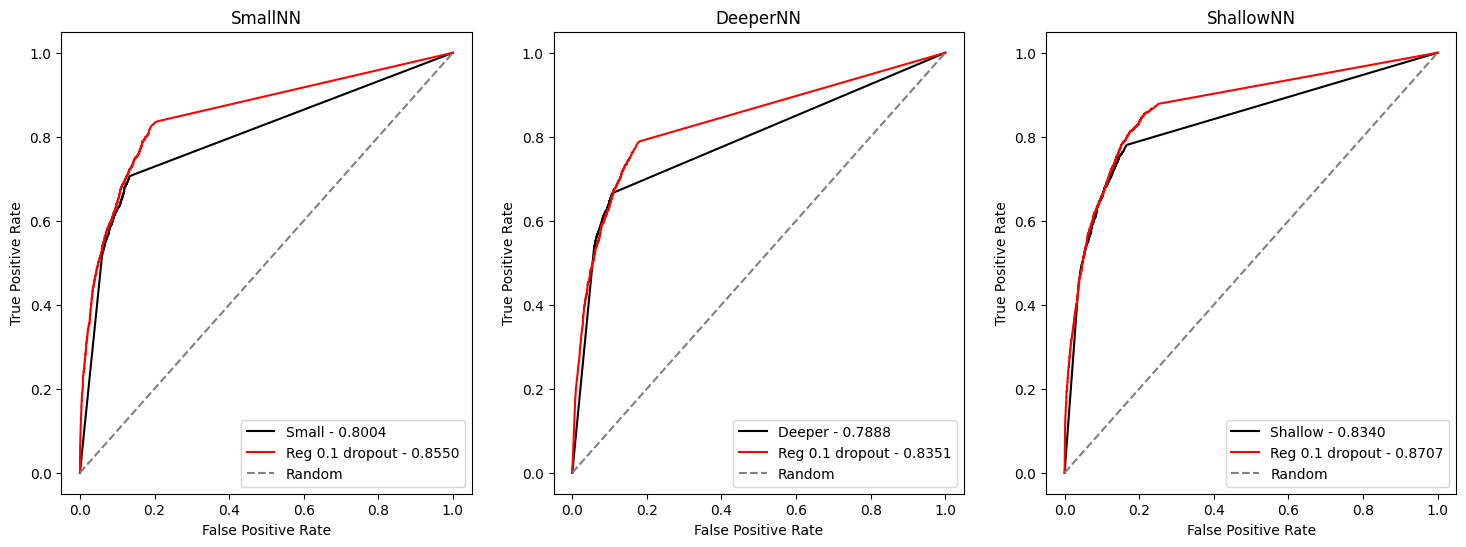

<Figure size 600x600 with 0 Axes>

In [7]:
plot_roc(y_val, adult_smallNN, adult_deeperNN, adult_shallowNN, adult_regSmallNN, adult_regDeeperNN, adult_regShallowNN, dataset_name)

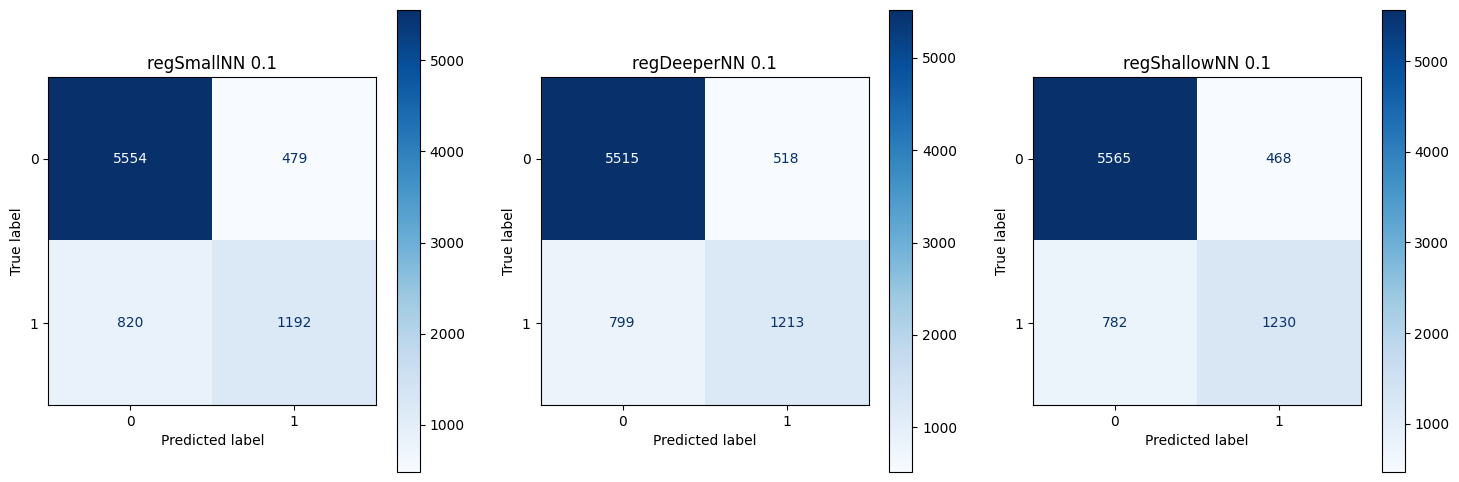

In [8]:
plot_conf_matrix(y_val, adult_regSmallNN, adult_regDeeperNN, adult_regShallowNN, title = ['regSmallNN 0.1', 'regDeeperNN 0.1', 'regShallowNN 0.1'])

# BANK

In [9]:
dataset_name = "bank"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

bank_smallNN, bank_acc_train_model1, bank_acc_val_model1 = eval_net(dataset_name, 'model1')
bank_deeperNN, bank_acc_train_model2, bank_acc_val_model2 = eval_net(dataset_name, 'model2')
bank_shallowNN, bank_acc_train_model3, bank_acc_val_model3 = eval_net(dataset_name, 'model3')

bank_regSmallNN, bank_acc_train_model1r, bank_acc_val_model1r = eval_net(dataset_name, 'model1r')
bank_regDeeperNN, bank_acc_train_model2r, bank_acc_val_model2r = eval_net(dataset_name, 'model2r')
bank_regShallowNN, bank_acc_train_model3r, bank_acc_val_model3r = eval_net(dataset_name, 'model3r')

(36168, 14) (8043, 14) (1000, 14)


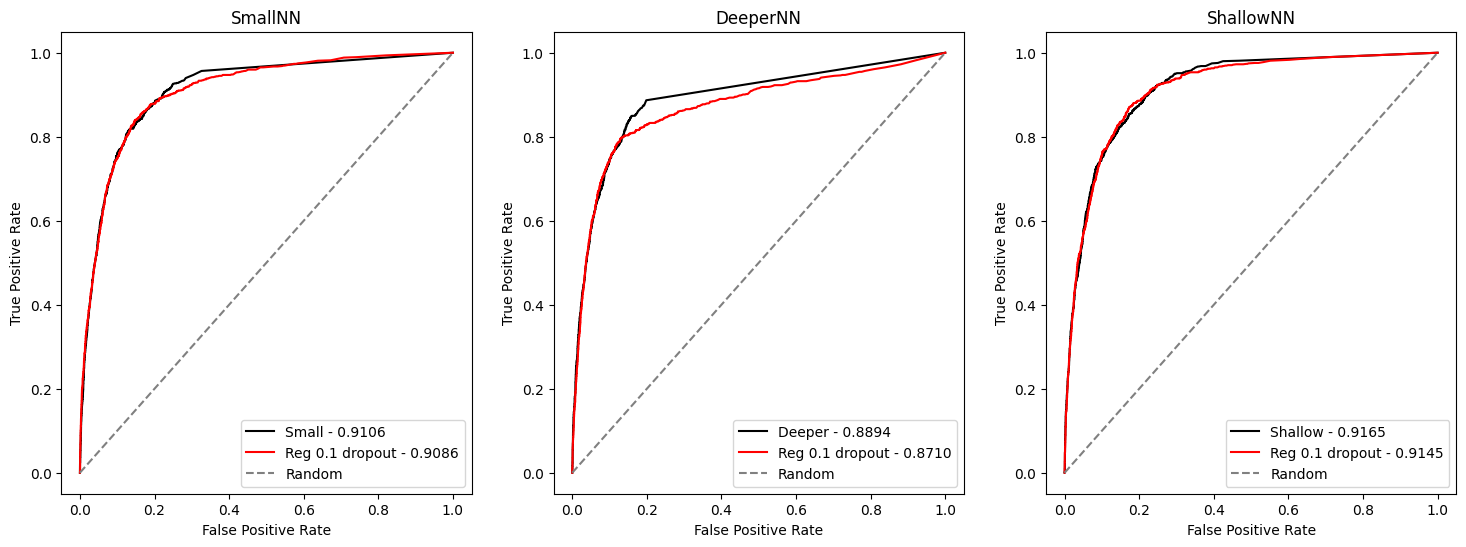

<Figure size 600x600 with 0 Axes>

In [10]:
plot_roc(y_val, bank_smallNN, bank_deeperNN, bank_shallowNN, bank_regSmallNN, bank_regDeeperNN, bank_regShallowNN, dataset_name)

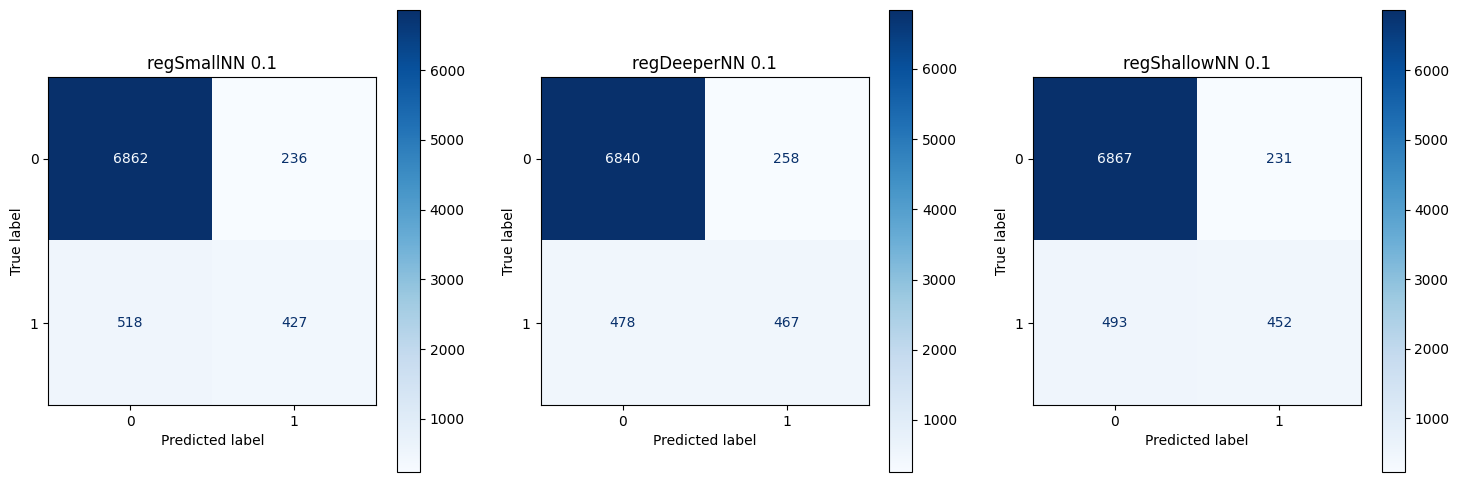

In [11]:
plot_conf_matrix(y_val, bank_regSmallNN, bank_regDeeperNN, bank_regShallowNN, title = ['regSmallNN 0.1', 'regDeeperNN 0.1', 'regShallowNN 0.1'])

# BEANS

In [12]:
dataset_name = "beans"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

beans_smallNN, beans_acc_train_model1, beans_acc_val_model1 = eval_net(dataset_name, 'model1')
beans_deeperNN, beans_acc_train_model2, beans_acc_val_model2 = eval_net(dataset_name, 'model2')
beans_shallowNN, beans_acc_train_model3, beans_acc_val_model3 = eval_net(dataset_name, 'model3')

beans_regSmallNN, beans_acc_train_model1r, beans_acc_val_model1r = eval_net(dataset_name, 'model1r')
beans_regDeeperNN, beans_acc_train_model2r, beans_acc_val_model2r = eval_net(dataset_name, 'model2r')
beans_regShallowNN, beans_acc_train_model3r, beans_acc_val_model3r = eval_net(dataset_name, 'model3r')

(10888, 7) (2223, 7) (500, 7)


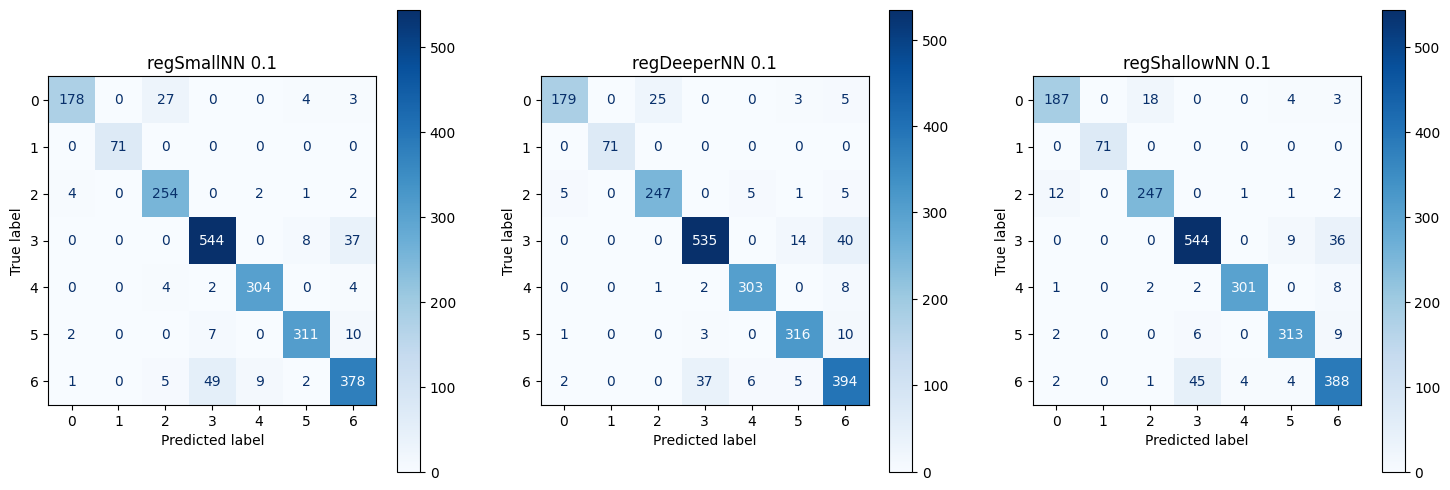

In [13]:
plot_conf_matrix(y_val, beans_regSmallNN, beans_regDeeperNN, beans_regShallowNN, title = ['regSmallNN 0.1', 'regDeeperNN 0.1', 'regShallowNN 0.1'])

# CANCER

In [14]:
dataset_name = "cancer"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

cancer_smallNN, cancer_acc_train_model1, cancer_acc_val_model1 = eval_net(dataset_name, 'model1')
cancer_deeperNN, cancer_acc_train_model2, cancer_acc_val_model2 = eval_net(dataset_name, 'model2')
cancer_shallowNN, cancer_acc_train_model3, cancer_acc_val_model3 = eval_net(dataset_name, 'model3')

cancer_regSmallNN, cancer_acc_train_model1r, cancer_acc_val_model1r = eval_net(dataset_name, 'model1r')
cancer_regDeeperNN, cancer_acc_train_model2r, cancer_acc_val_model2r = eval_net(dataset_name, 'model2r')
cancer_regShallowNN, cancer_acc_train_model3r, cancer_acc_val_model3r = eval_net(dataset_name, 'model3r')

(397, 15) (121, 15) (50, 15)


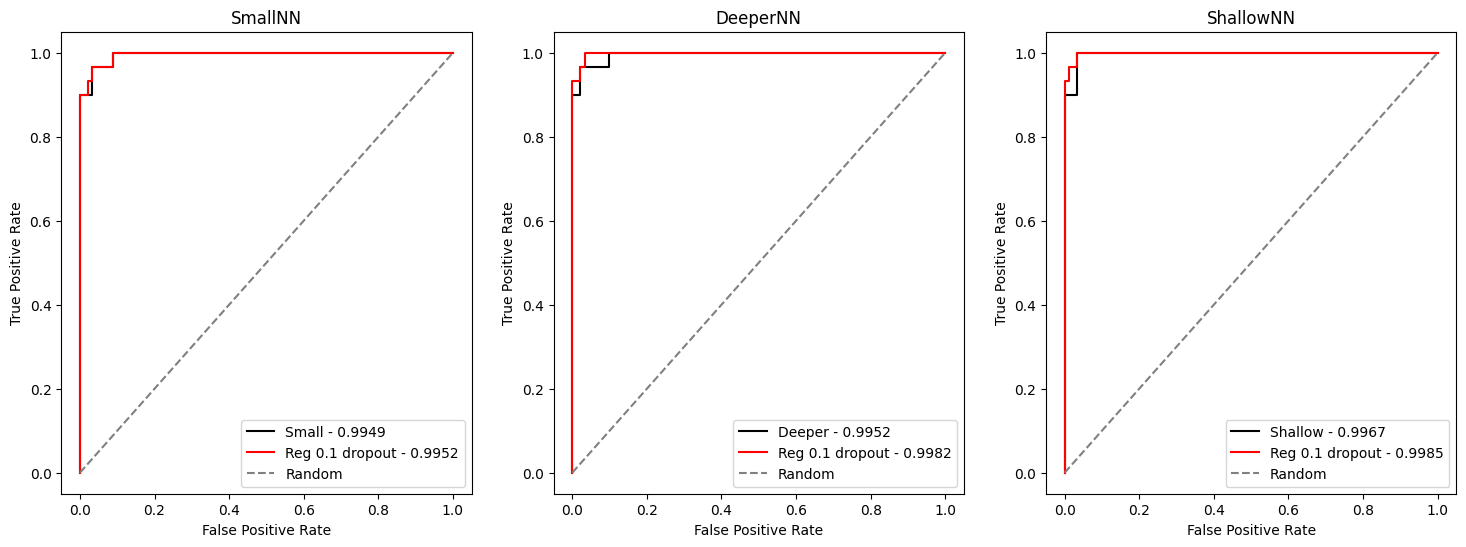

<Figure size 600x600 with 0 Axes>

In [15]:
plot_roc(y_val, cancer_smallNN, cancer_deeperNN, cancer_shallowNN, cancer_regSmallNN, cancer_regDeeperNN, cancer_regShallowNN, dataset_name)

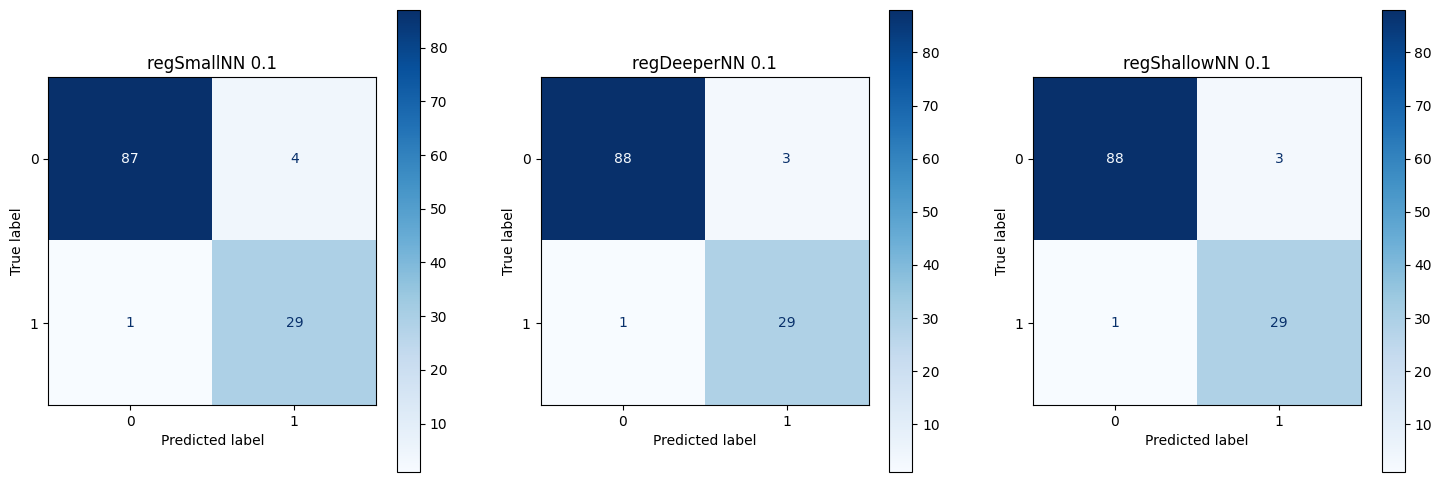

In [16]:
plot_conf_matrix(y_val, cancer_regSmallNN, cancer_regDeeperNN, cancer_regShallowNN, title = ['regSmallNN 0.1', 'regDeeperNN 0.1', 'regShallowNN 0.1'])

# HELOC

In [17]:
dataset_name = "heloc"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

heloc_smallNN, heloc_acc_train_model1, heloc_acc_val_model1 = eval_net(dataset_name, 'model1')
heloc_deeperNN, heloc_acc_train_model2, heloc_acc_val_model2 = eval_net(dataset_name, 'model2')
heloc_shallowNN, heloc_acc_train_model3, heloc_acc_val_model3 = eval_net(dataset_name, 'model3')

heloc_regSmallNN, heloc_acc_train_model1r, heloc_acc_val_model1r = eval_net(dataset_name, 'model1r')
heloc_regDeeperNN, heloc_acc_train_model2r, heloc_acc_val_model2r = eval_net(dataset_name, 'model2r')
heloc_regShallowNN, heloc_acc_train_model3r, heloc_acc_val_model3r = eval_net(dataset_name, 'model3r')

(8367, 16) (1592, 16) (500, 16)


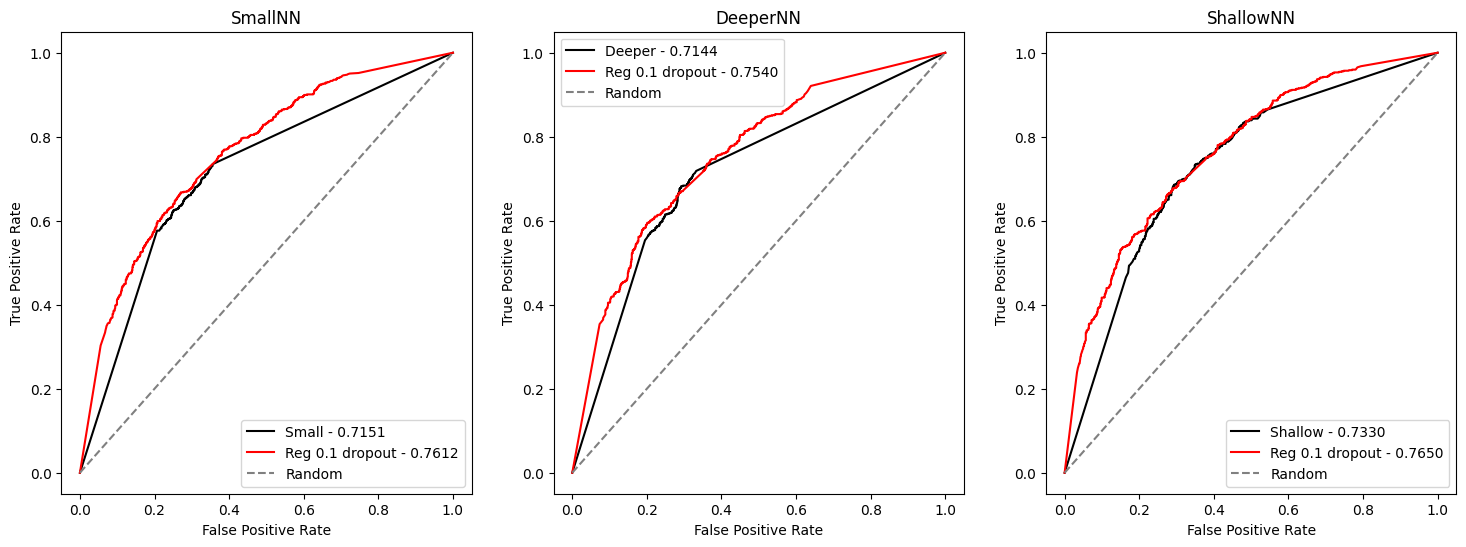

<Figure size 600x600 with 0 Axes>

In [18]:
plot_roc(y_val, heloc_smallNN, heloc_deeperNN, heloc_shallowNN, heloc_regSmallNN, heloc_regDeeperNN, heloc_regShallowNN, dataset_name)

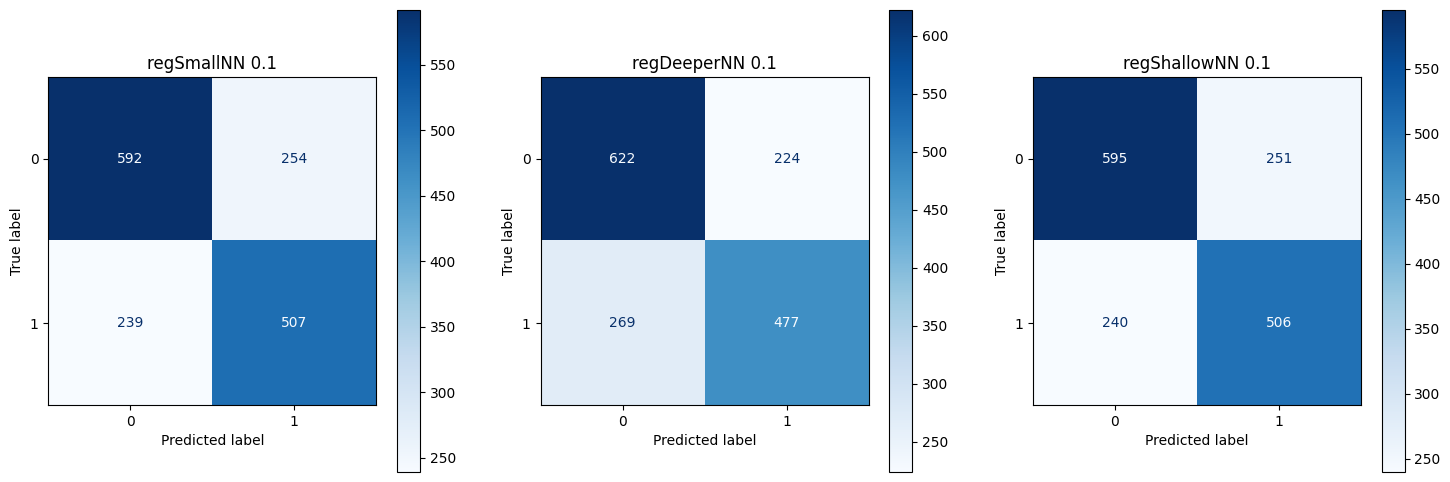

In [19]:
plot_conf_matrix(y_val, heloc_regSmallNN, heloc_regDeeperNN, heloc_regShallowNN, title = ['regSmallNN 0.1', 'regDeeperNN 0.1', 'regShallowNN 0.1'])

# MUSHROOMS

In [20]:
dataset_name = "mushroom"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

mushroom_smallNN, mushroom_acc_train_model1, mushroom_acc_val_model1 = eval_net(dataset_name, 'model1')
mushroom_deeperNN, mushroom_acc_train_model2, mushroom_acc_val_model2 = eval_net(dataset_name, 'model2')
mushroom_shallowNN, mushroom_acc_train_model3, mushroom_acc_val_model3 = eval_net(dataset_name, 'model3')

mushroom_regSmallNN, mushroom_acc_train_model1r, mushroom_acc_val_model1r = eval_net(dataset_name, 'model1r')
mushroom_regDeeperNN, mushroom_acc_train_model2r, mushroom_acc_val_model2r = eval_net(dataset_name, 'model2r')
mushroom_regShallowNN, mushroom_acc_train_model3r, mushroom_acc_val_model3r = eval_net(dataset_name, 'model3r')

(6498, 21) (1225, 21) (400, 21)


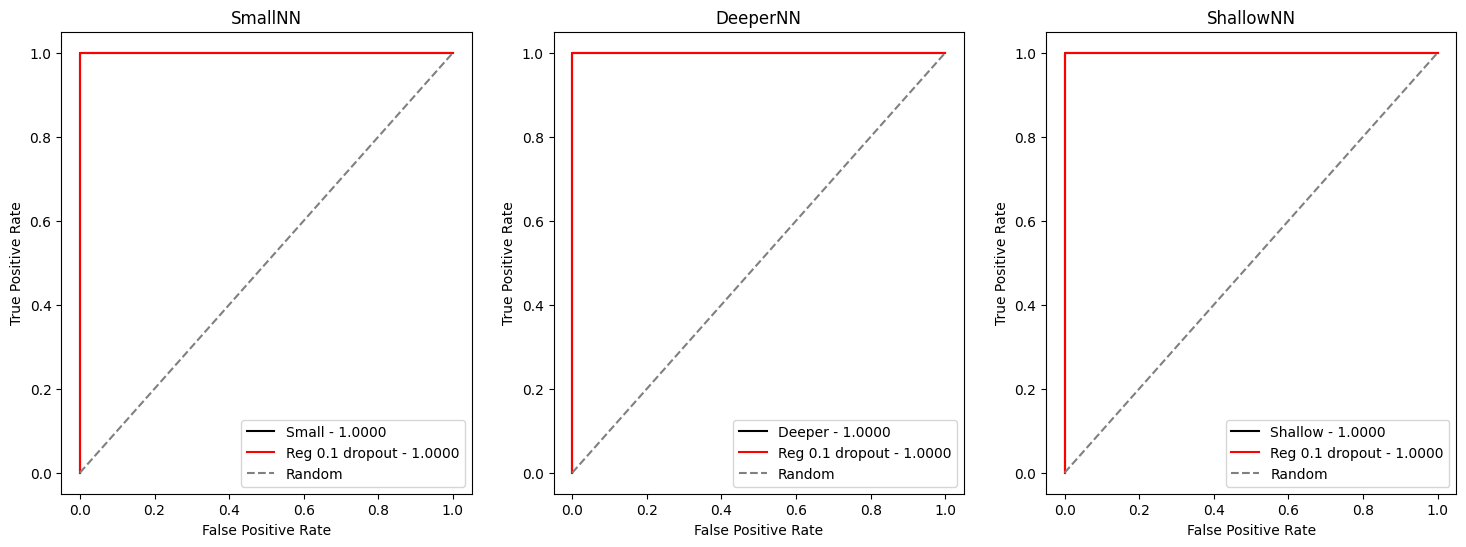

<Figure size 600x600 with 0 Axes>

In [21]:
plot_roc(y_val, mushroom_smallNN, mushroom_deeperNN, mushroom_shallowNN, mushroom_regSmallNN, mushroom_regDeeperNN, mushroom_regShallowNN, dataset_name)

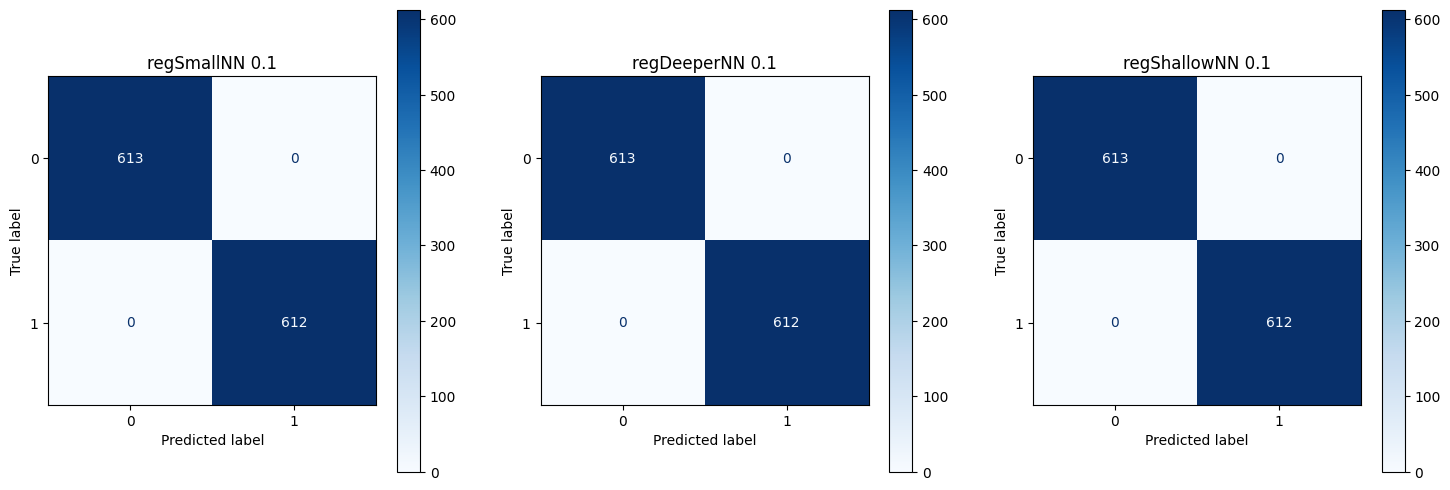

In [22]:
plot_conf_matrix(y_val, mushroom_regSmallNN, mushroom_regDeeperNN, mushroom_regShallowNN, title = ['regSmallNN 0.1', 'regDeeperNN 0.1', 'regShallowNN 0.1'])

# OCEAN

In [23]:
dataset_name = "ocean"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

ocean_smallNN, ocean_acc_train_model1, ocean_acc_val_model1 = eval_net(dataset_name, 'model1')
ocean_deeperNN, ocean_acc_train_model2, ocean_acc_val_model2 = eval_net(dataset_name, 'model2')
ocean_shallowNN, ocean_acc_train_model3, ocean_acc_val_model3 = eval_net(dataset_name, 'model3')

ocean_regSmallNN, ocean_acc_train_model1r, ocean_acc_val_model1r = eval_net(dataset_name, 'model1r')
ocean_regDeeperNN, ocean_acc_train_model2r, ocean_acc_val_model2r = eval_net(dataset_name, 'model2r')
ocean_regShallowNN, ocean_acc_train_model3r, ocean_acc_val_model3r = eval_net(dataset_name, 'model3r')

(109259, 8) (30328, 8) (10000, 8)


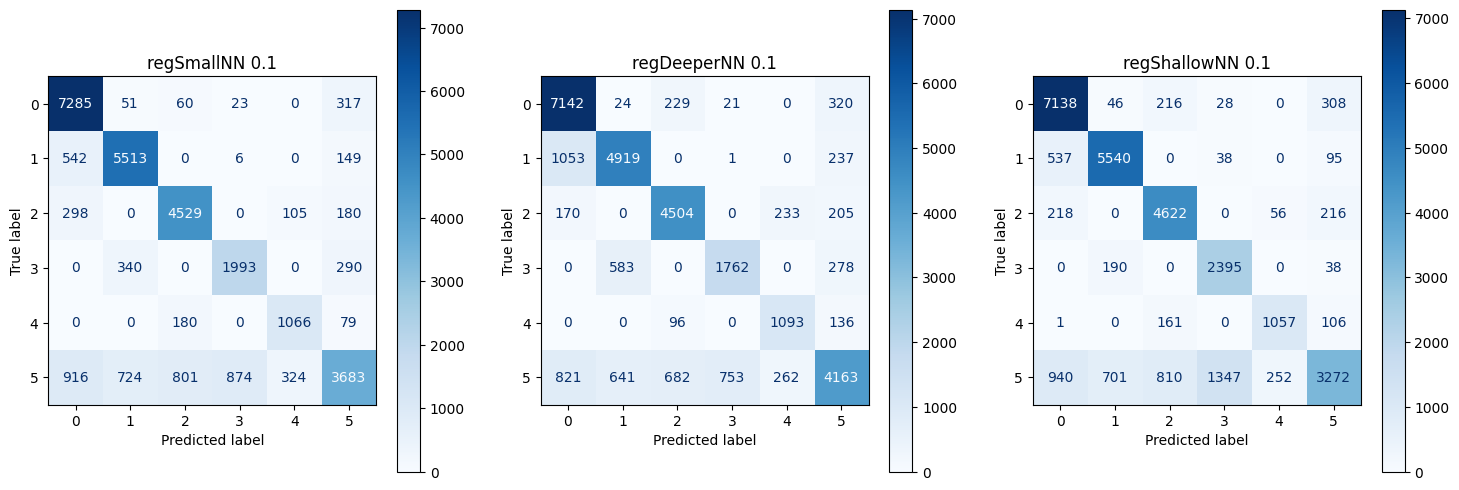

In [24]:
plot_conf_matrix(y_val, ocean_regSmallNN, ocean_regDeeperNN, ocean_regShallowNN, title = ['regSmallNN 0.1', 'regDeeperNN 0.1', 'regShallowNN 0.1'])

# WINE

In [25]:
dataset_name = "wine"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

wine_smallNN, wine_acc_train_model1, wine_acc_val_model1 = eval_net(dataset_name, 'model1')
wine_deeperNN, wine_acc_train_model2, wine_acc_val_model2 = eval_net(dataset_name, 'model2')
wine_shallowNN, wine_acc_train_model3, wine_acc_val_model3 = eval_net(dataset_name, 'model3')

wine_regSmallNN, wine_acc_train_model1r, wine_acc_val_model1r = eval_net(dataset_name, 'model1r')
wine_regDeeperNN, wine_acc_train_model2r, wine_acc_val_model2r = eval_net(dataset_name, 'model2r')
wine_regShallowNN, wine_acc_train_model3r, wine_acc_val_model3r = eval_net(dataset_name, 'model3r')

(3918, 9) (780, 9) (200, 9)


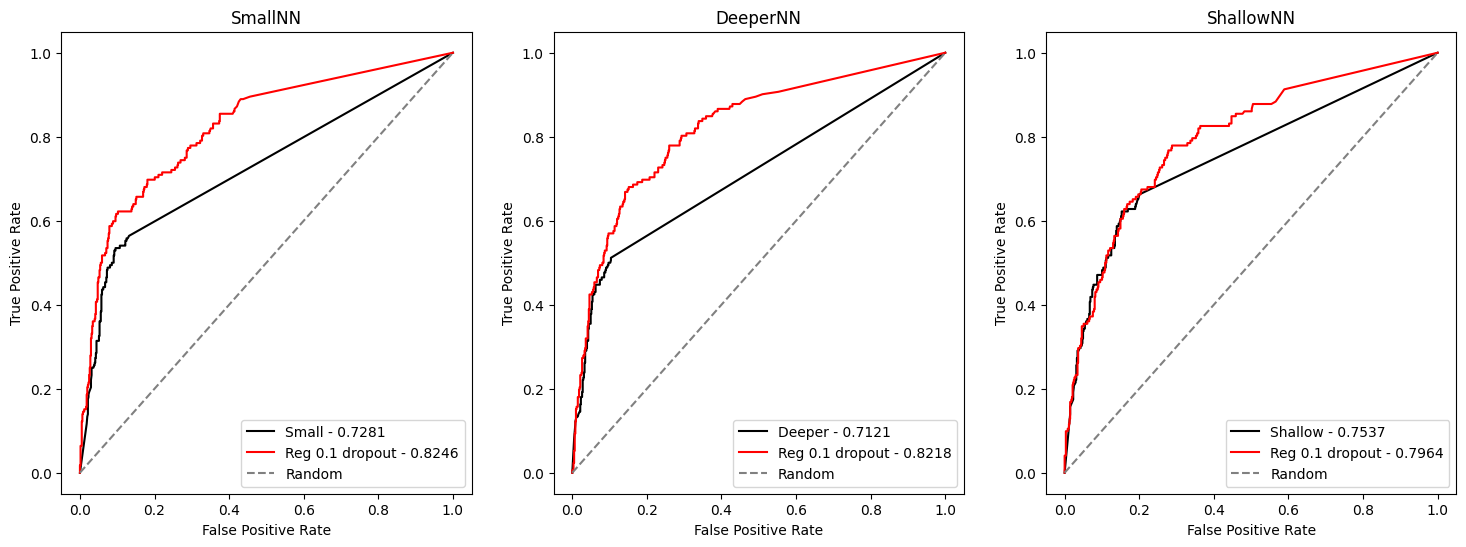

<Figure size 600x600 with 0 Axes>

In [26]:
plot_roc(y_val, wine_smallNN, wine_deeperNN, wine_shallowNN, wine_regSmallNN, wine_regDeeperNN, wine_regShallowNN, dataset_name)

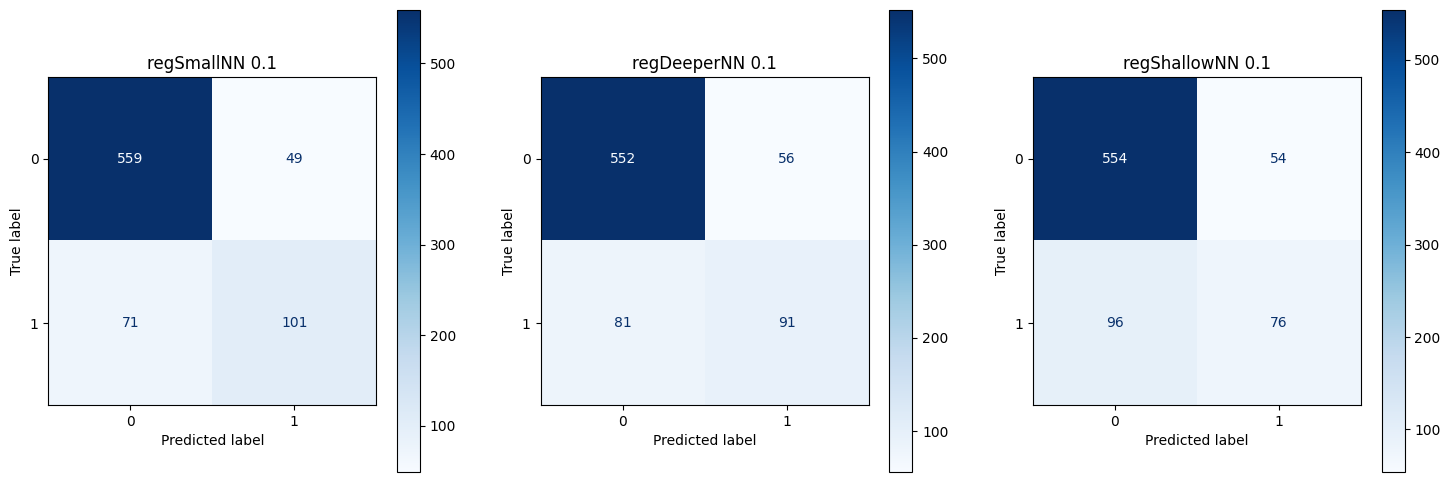

In [27]:
plot_conf_matrix(y_val, wine_regSmallNN, wine_regDeeperNN, wine_regShallowNN, title = ['regSmallNN 0.1', 'regDeeperNN 0.1', 'regShallowNN 0.1'])

# Model accuracy comparability

In [30]:
set = 'train'
print(f"    {set}\n")

if set == 'val':
    data = [
        ["adult", adult_acc_val_model1, adult_acc_val_model2, adult_acc_val_model3, adult_acc_val_model1r, adult_acc_val_model2r, adult_acc_val_model3r],
        ["bank", bank_acc_val_model1, bank_acc_val_model2, bank_acc_val_model3, bank_acc_val_model1r, bank_acc_val_model2r, bank_acc_val_model3r],
        ["beans", beans_acc_val_model1, beans_acc_val_model2, beans_acc_val_model3, beans_acc_val_model1r, beans_acc_val_model2r, beans_acc_val_model3r],
        ["cancer", cancer_acc_val_model1, cancer_acc_val_model2, cancer_acc_val_model3, cancer_acc_val_model1r, cancer_acc_val_model2r, cancer_acc_val_model3r],
        ["heloc", heloc_acc_val_model1, heloc_acc_val_model2, heloc_acc_val_model3, heloc_acc_val_model1r, heloc_acc_val_model2r, heloc_acc_val_model3r],
        ["mushroom", mushroom_acc_val_model1, mushroom_acc_val_model2, mushroom_acc_val_model3, mushroom_acc_val_model1r, mushroom_acc_val_model2r, mushroom_acc_val_model3r],
        ["ocean", ocean_acc_val_model1, ocean_acc_val_model2, ocean_acc_val_model3, ocean_acc_val_model1r, ocean_acc_val_model2r, ocean_acc_val_model3r],
        ["wine", wine_acc_val_model1, wine_acc_val_model2, wine_acc_val_model3, wine_acc_val_model1r, wine_acc_val_model2r, wine_acc_val_model3r]
    ]
else:
    data = [
        ["adult", adult_acc_train_model1, adult_acc_train_model2, adult_acc_train_model3, adult_acc_train_model1r, adult_acc_train_model2r, adult_acc_train_model3r],
        ["bank", bank_acc_train_model1, bank_acc_train_model2, bank_acc_train_model3, bank_acc_train_model1r, bank_acc_train_model2r, bank_acc_train_model3r],
        ["beans", beans_acc_train_model1, beans_acc_train_model2, beans_acc_train_model3, beans_acc_train_model1r, beans_acc_train_model2r, beans_acc_train_model3r],
        ["cancer", cancer_acc_train_model1, cancer_acc_train_model2, cancer_acc_train_model3, cancer_acc_train_model1r, cancer_acc_train_model2r, cancer_acc_train_model3r],
        ["heloc", heloc_acc_train_model1, heloc_acc_train_model2, heloc_acc_train_model3, heloc_acc_train_model1r, heloc_acc_train_model2r, heloc_acc_train_model3r],
        ["mushroom", mushroom_acc_train_model1, mushroom_acc_train_model2, mushroom_acc_train_model3, mushroom_acc_train_model1r, mushroom_acc_train_model2r, mushroom_acc_train_model3r],
        ["ocean", ocean_acc_train_model1, ocean_acc_train_model2, ocean_acc_train_model3, ocean_acc_train_model1r, ocean_acc_train_model2r, ocean_acc_train_model3r],
        ["wine", wine_acc_train_model1, wine_acc_train_model2, wine_acc_train_model3, wine_acc_train_model1r, wine_acc_train_model2r, wine_acc_train_model3r]
    ]

headers = ["Dataset", "model 1", "model 2", "model 3", "model 1r", "model 2r", "model 3r"]
print(tabulate(data, headers=headers, tablefmt="github", floatfmt=".4f"))

    train

| Dataset   |   model 1 |   model 2 |   model 3 |   model 1r |   model 2r |   model 3r |
|-----------|-----------|-----------|-----------|------------|------------|------------|
| adult     |    0.9110 |    0.9056 |    0.9083 |     0.8883 |     0.9014 |     0.8763 |
| bank      |    0.9148 |    0.9069 |    0.9132 |     0.9093 |     0.9089 |     0.9079 |
| beans     |    0.9351 |    0.9327 |    0.8935 |     0.9051 |     0.8870 |     0.8894 |
| cancer    |    0.9975 |    0.9975 |    0.9950 |     0.9798 |     0.9798 |     0.9673 |
| heloc     |    0.8534 |    0.8562 |    0.8519 |     0.7882 |     0.7972 |     0.7766 |
| mushroom  |    1.0000 |    1.0000 |    1.0000 |     0.9998 |     1.0000 |     0.9994 |
| ocean     |    0.9202 |    0.7710 |    0.9242 |     0.7860 |     0.8372 |     0.7710 |
| wine      |    0.8943 |    0.8908 |    0.8675 |     0.8540 |     0.8481 |     0.8295 |
